# CV analysis: 4 Day 10% formalin-fixed decell tissue - 2026-06-16 (FORCE)

Pairs the scope **force**-sensor log with the potentiostat CV log from the same run.
**Three scans**, +1 V -> -1 V -> +1 V at **2.5 mV/s**. Scan 1 is a conditioning/equilibration
sweep; the later cycles carry the real actuation.

- Force signal is on scope **CH2 (CH1 is 0)**.
- Geometry (cross-section / L0) is read from `sizes.csv` for `4_DAY`.
- Scope and potentiostat were started simultaneously (offset = 0 s).

Sections: raw closed-loop CV plots -> focused later-cycle loops -> **linear slippage correction**
(global fit to the top-of-scan +1 V reference points) -> slippage-corrected replot.

In [1]:
# === Per-run configuration (THE ONLY cell that differs between the 6 notebooks) ===
import os
BASE          = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.16.26_formalin_fixed_decell_chicken_experiments'
DAY_KEY       = '4_DAY'            # row key into sizes.csv
MODE          = 'FORCE'           # 'FORCE' or 'LENGTH'
SCOPE_CSV     = os.path.join(BASE, '4day_10%_formalin_fixed_FORCE_scope_log_20260616_141521.csv')
POTEN_CSV     = os.path.join(BASE, 'potentiostat/06.16.26-4Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv')
SIZES_CSV     = os.path.join(BASE, 'sizes.csv')
SCOPE_CHANNEL = 'ch2_MEAN_V'      # FORCE signal is on CH2 (CH1 is 0)

SCAN_RATE_V_PER_S = 0.0025          # 2.5 mV/s
WINDOW = 41                         # MAD outlier-filter rolling window (samples)
K = 5.0                             # outlier threshold (multiples of MAD)
print(f'{DAY_KEY} {MODE}  scope={os.path.basename(SCOPE_CSV)}  poten={os.path.basename(POTEN_CSV)}')

4_DAY FORCE  scope=4day_10%_formalin_fixed_FORCE_scope_log_20260616_141521.csv  poten=06.16.26-4Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv


In [2]:
# Load both files, align (offset = 0), filter scope outliers, map to applied voltage + cycle index.
import io, csv
import numpy as np
import pandas as pd

# ---- 1. Potentiostat (UTF-16, 6-line header, N scans side by side) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('﻿', '')
lines = text.splitlines()
rows = list(csv.reader(io.StringIO('\n'.join(lines[6:]))))
rows = [r for r in rows if r and r[0]]
n_scans = len(rows[0]) // 2                       # 2 columns (V, microA) per scan
cols = []
for s in range(n_scans):
    cols += [f'v{s+1}', f'i{s+1}_uA']
poten = pd.DataFrame([[float(x) for x in r[:2*n_scans]] for r in rows], columns=cols)
n_per_scan = len(poten)
print(f'Potentiostat: {n_scans} scans (cycles), {n_per_scan} samples/scan')

# ---- 2. Derive sample interval from the recorded voltage step + scan rate ----
# Each scan ramps +1 V -> -1 V -> +1 V at a fixed 2.5 mV/s. The downward leg from sample 0
# to the argmin spans a known voltage delta, so DT = |dV| / scan_rate.
v1 = poten['v1'].values
turn_idx = int(np.argmin(v1))
DT = abs(v1[0] - v1[turn_idx]) / turn_idx / SCAN_RATE_V_PER_S
per_scan_s = n_per_scan * DT
exp_total_s = n_scans * per_scan_s
print(f'Derived DT = {DT:.4f} s/sample  ->  {per_scan_s:.1f} s/cycle, {exp_total_s:.1f} s total')

t_scan = np.arange(n_per_scan) * DT
t_exp_full = np.concatenate([t_scan + s*per_scan_s for s in range(n_scans)])
v_applied_full = np.concatenate([poten[f'v{s+1}'].values for s in range(n_scans)])

# ---- 3. Scope log + alignment (offset = 0; scope and potentiostat started together) ----
scope = pd.read_csv(SCOPE_CSV)
scope['t_exp'] = scope['elapsed_s']
scope_in = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= exp_total_s)].copy()
print(f'Scope rows in experiment window: {len(scope_in)} / {len(scope)} '
      f'(max elapsed {scope["elapsed_s"].max():.1f} s)')

# ---- 4. Outlier filter (rolling-median + MAD) ----
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad_floor = max(np.nanstd(x) * 1e-3, 1e-9)
    mad = mad.clip(lower=mad_floor)
    return (abs_dev > k * mad).values

mask = mark_outliers(scope_in[SCOPE_CHANNEL].values, window=WINDOW, k=K)
print(f'Flagged {mask.sum()} of {len(scope_in)} in-window scope samples '
      f'({mask.sum()/max(len(scope_in),1)*100:.2f}%) as outliers.')
scope_clean = scope_in.loc[~mask].copy()

# ---- 5. Map scope samples to applied voltage + cycle index ----
scope_clean['v_applied'] = np.interp(scope_clean['t_exp'].values, t_exp_full, v_applied_full)
scope_clean['cycle'] = np.clip((scope_clean['t_exp'].values // per_scan_s).astype(int), 0, n_scans-1)
for c in range(n_scans):
    print(f'Cycle {c+1} scope rows:', (scope_clean['cycle'] == c).sum())
scope_clean.head()

Potentiostat: 3 scans (cycles), 4034 samples/scan
Derived DT = 0.3967 s/sample  ->  1600.4 s/cycle, 4801.3 s total
Scope rows in experiment window: 9708 / 9718 (max elapsed 4806.1 s)
Flagged 24 of 9708 in-window scope samples (0.25%) as outliers.
Cycle 1 scope rows: 3259
Cycle 2 scope rows: 3204
Cycle 3 scope rows: 3221


,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,t_exp,v_applied,cycle
0,0.5003,2026-06-16T14:15:21.583902,0.0,5.120376,0.5003,0.998762,0
1,1.0156,2026-06-16T14:15:22.099181,0.0,5.120200,1.0156,0.997487,0
2,1.5184,2026-06-16T14:15:22.601986,0.0,5.119768,1.5184,0.996234,0
3,2.0192,2026-06-16T14:15:23.102795,0.0,5.119224,2.0192,0.994959,0
4,2.4992,2026-06-16T14:15:23.582783,0.0,5.118032,2.4992,0.993801,0


In [3]:
# Calibration + geometry (from sizes.csv) and shared smoothing / loop-closing helpers.
# MODE switches the value channel: FORCE -> mN & stress(MPa);  LENGTH -> mm & strain(%).
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

FORCE_GAIN_MN_PER_V  = 56.7        # 1x gain (all days)
LENGTH_COEF_MM_PER_V = -0.4130     # 1x gain (all days)

sizes = pd.read_csv(SIZES_CSV).set_index('formalin_fixation_time')
row = sizes.loc[DAY_KEY]
L0_MM      = float(row['length(mm)'])
WIDTH_MM   = float(row['width(mm)'])
THICKNESS_MM = float(row['thickness(mm)'])
AREA_MM2   = WIDTH_MM * THICKNESS_MM
print(f'{DAY_KEY} geometry: L0={L0_MM} mm, W={WIDTH_MM} mm, T={THICKNESS_MM} mm, A={AREA_MM2:.3f} mm^2')

if MODE == 'FORCE':
    VALUE_COEF  = FORCE_GAIN_MN_PER_V          # scope-V -> mN
    VALUE_COL   = 'force_mN'
    VALUE_LABEL = 'Force (mN)'
    def to_sec(f):   return f / AREA_MM2 / 1000.0     # mN -> MPa  (1 mN/mm^2 = 1 kPa)
    def from_sec(s): return s * AREA_MM2 * 1000.0
    SEC_LABEL = f'Stress (MPa)  [A = {WIDTH_MM} x {THICKNESS_MM} = {AREA_MM2:.3f} mm^2]'
    RATE_UNIT = 'mN/s'
else:
    VALUE_COEF  = LENGTH_COEF_MM_PER_V         # scope-V -> mm
    VALUE_COL   = 'dist_mm'
    VALUE_LABEL = f'Distance (mm)  [{LENGTH_COEF_MM_PER_V:.4f} mm/V, 1x gain]'
    def to_sec(d):   return d / L0_MM * 100.0         # mm -> % strain
    def from_sec(s): return s * L0_MM / 100.0
    SEC_LABEL = f'Strain (%)  [L0 = {L0_MM} mm]'
    RATE_UNIT = 'mm/s'

PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
SMOOTH_WINDOW, SAVGOL_POLY, RAW_ALPHA = 101, 3, 0.20


def savgol_per_cycle(df, value_col, window=101, poly=3):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        y = sub[value_col].values
        n = len(y)
        if n < 3:
            out.loc[sub.index] = y
            continue
        w = min(window, n)
        if w % 2 == 0:
            w -= 1
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out


def close_loop_per_cycle(df, value_col, smooth_col):
    """Subtract a per-cycle linear-in-time drift so each cycle's last smoothed sample equals
    its first -- value(end-+1 V) == value(start-+1 V), closing the loop."""
    out = df[value_col].astype(float).copy()
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        t = sub['t_exp'].values
        y = sub[smooth_col].values
        if len(sub) < 2 or t[-1] == t[0]:
            continue
        slope = (y[-1] - y[0]) / (t[-1] - t[0])
        out.loc[sub.index] = df.loc[sub.index, value_col].values - slope * (t - t[0])
    return out

# Physical value, smoothed, and per-cycle creep-corrected (closed-loop) version.
scope_clean[VALUE_COL]       = scope_clean[SCOPE_CHANNEL] * VALUE_COEF
scope_clean['smooth']        = savgol_per_cycle(scope_clean, VALUE_COL, SMOOTH_WINDOW, SAVGOL_POLY)
scope_clean['value_closed']  = close_loop_per_cycle(scope_clean, VALUE_COL, 'smooth')
scope_clean['smooth_closed'] = savgol_per_cycle(scope_clean, 'value_closed', SMOOTH_WINDOW, SAVGOL_POLY)

print('Per-cycle loop-closure gap (end - start of smoothed value):')
for c in range(n_scans):
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')
    g0 = sub['smooth'].values[-1]        - sub['smooth'].values[0]
    g1 = sub['smooth_closed'].values[-1] - sub['smooth_closed'].values[0]
    print(f'  cycle {c+1}: before = {g0:+9.4f}   ->   after = {g1:+9.4f}')

4_DAY geometry: L0=11.0 mm, W=3.4 mm, T=0.374 mm, A=1.272 mm^2
Per-cycle loop-closure gap (end - start of smoothed value):
  cycle 1: before =  -15.9798   ->   after =   -0.0008
  cycle 2: before =  +31.5840   ->   after =   +0.0009
  cycle 3: before =  +24.4354   ->   after =   -0.0000


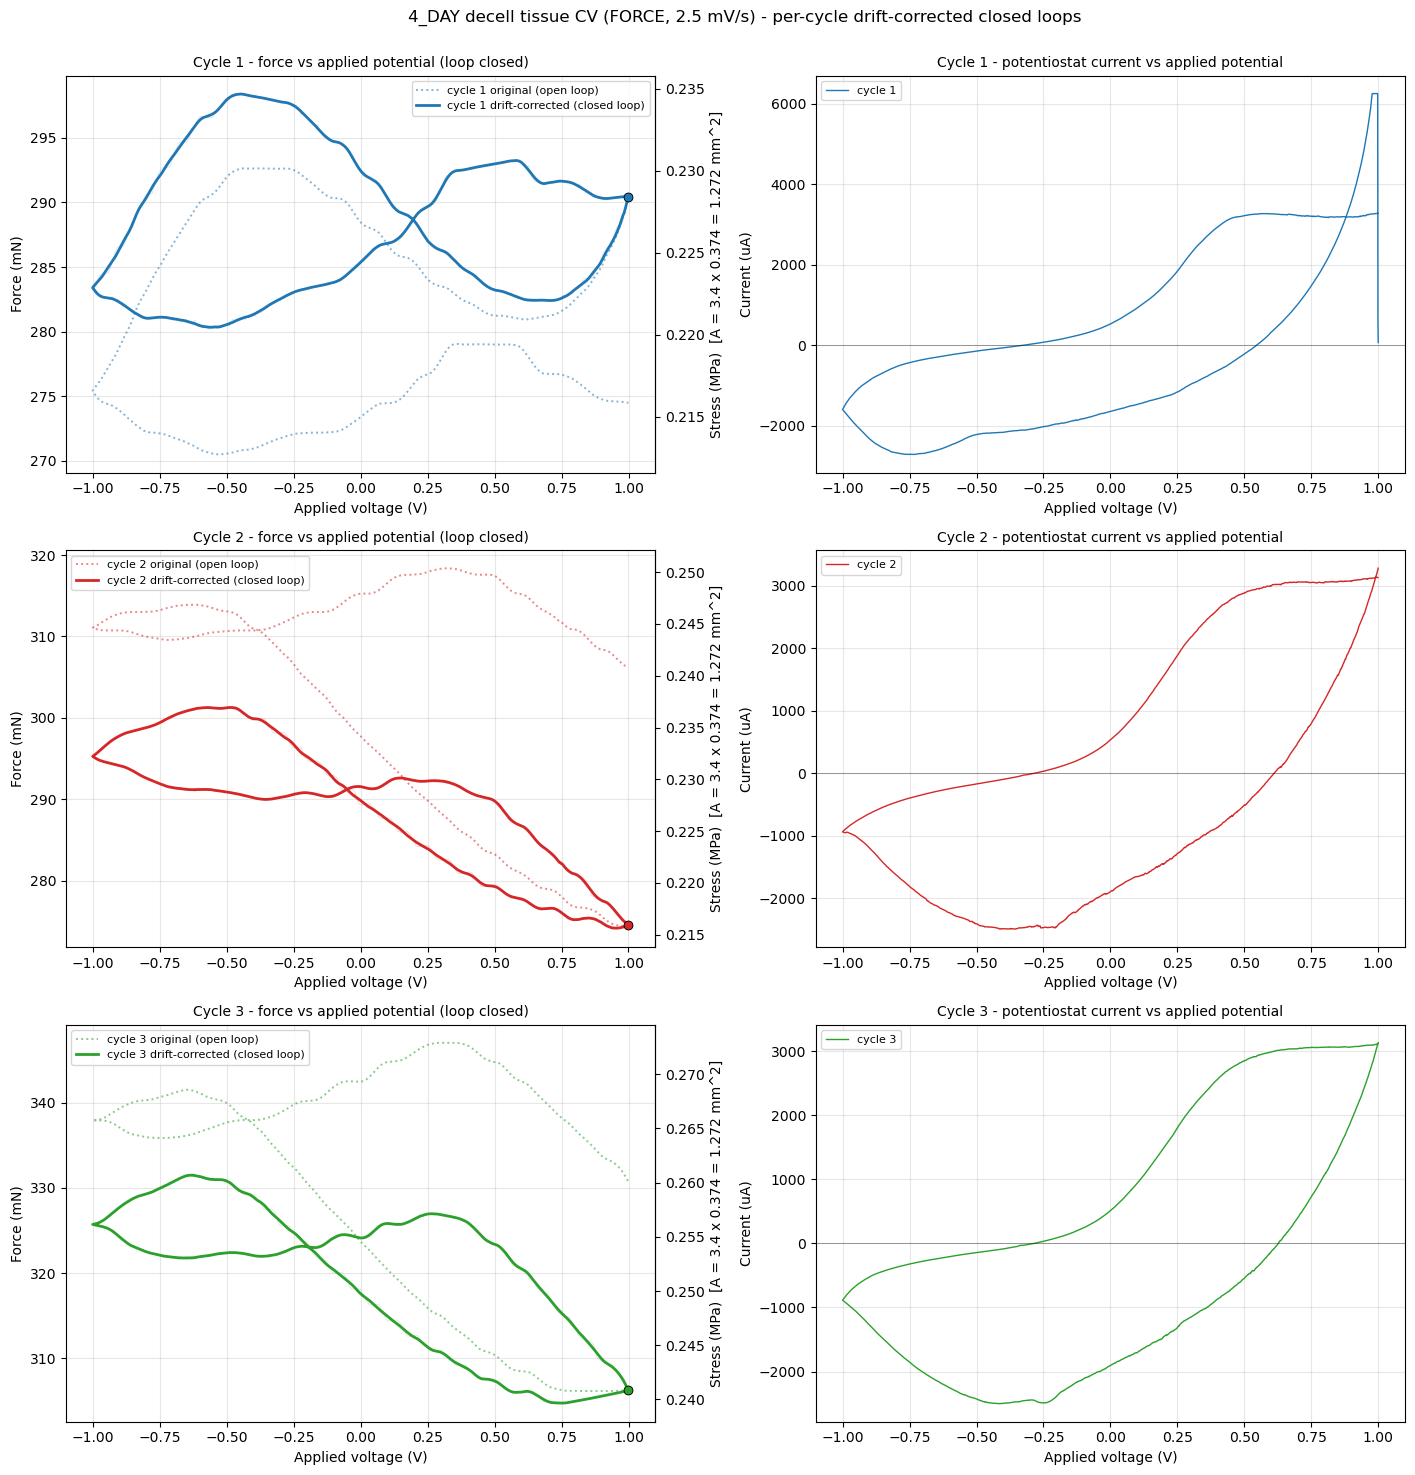

In [4]:
# Rows = cycles; columns = (value vs applied voltage [closed loop], potentiostat current vs voltage).
# Each cycle sweeps +1 V -> -1 V -> +1 V and returns to its start, so absent creep/slippage the loop
# should close. We remove a per-cycle linear-in-time drift and draw the original (open) loop dotted
# behind the corrected (closed) solid loop.
fig, axes = plt.subplots(n_scans, 2, figsize=(15, 5*n_scans), squeeze=False)
for c in range(n_scans):
    color = PALETTE[c % len(PALETTE)]
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')

    ax = axes[c, 0]
    ax.plot(sub['v_applied'], sub['smooth'], color=color, lw=1.4, ls=':', alpha=0.55,
            label=f'cycle {c+1} original (open loop)')
    ax.plot(sub['v_applied'], sub['value_closed'], color=color, lw=0.6, alpha=RAW_ALPHA)
    ax.plot(sub['v_applied'], sub['smooth_closed'], color=color, lw=2.0,
            label=f'cycle {c+1} drift-corrected (closed loop)')
    ax.scatter([sub['v_applied'].values[0], sub['v_applied'].values[-1]],
               [sub['smooth_closed'].values[0], sub['smooth_closed'].values[-1]],
               color=color, zorder=5, s=40, ec='k', lw=0.5)
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel(VALUE_LABEL)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax_s = ax.secondary_yaxis('right', functions=(to_sec, from_sec))
    ax_s.set_ylabel(SEC_LABEL)
    ax.set_title(f'Cycle {c+1} - {MODE.lower()} vs applied potential (loop closed)', fontsize=10)

    axc = axes[c, 1]
    axc.plot(poten[f'v{c+1}'], poten[f'i{c+1}_uA'], color=color, lw=1.0, label=f'cycle {c+1}')
    axc.set_xlabel('Applied voltage (V)')
    axc.set_ylabel('Current (uA)')
    axc.axhline(0, color='k', lw=0.5, alpha=0.5)
    axc.grid(True, alpha=0.3)
    axc.legend(loc='best', fontsize=8)
    axc.set_title(f'Cycle {c+1} - potentiostat current vs applied potential', fontsize=10)

fig.suptitle(f'{DAY_KEY} decell tissue CV ({MODE}, 2.5 mV/s) - per-cycle drift-corrected closed loops',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()

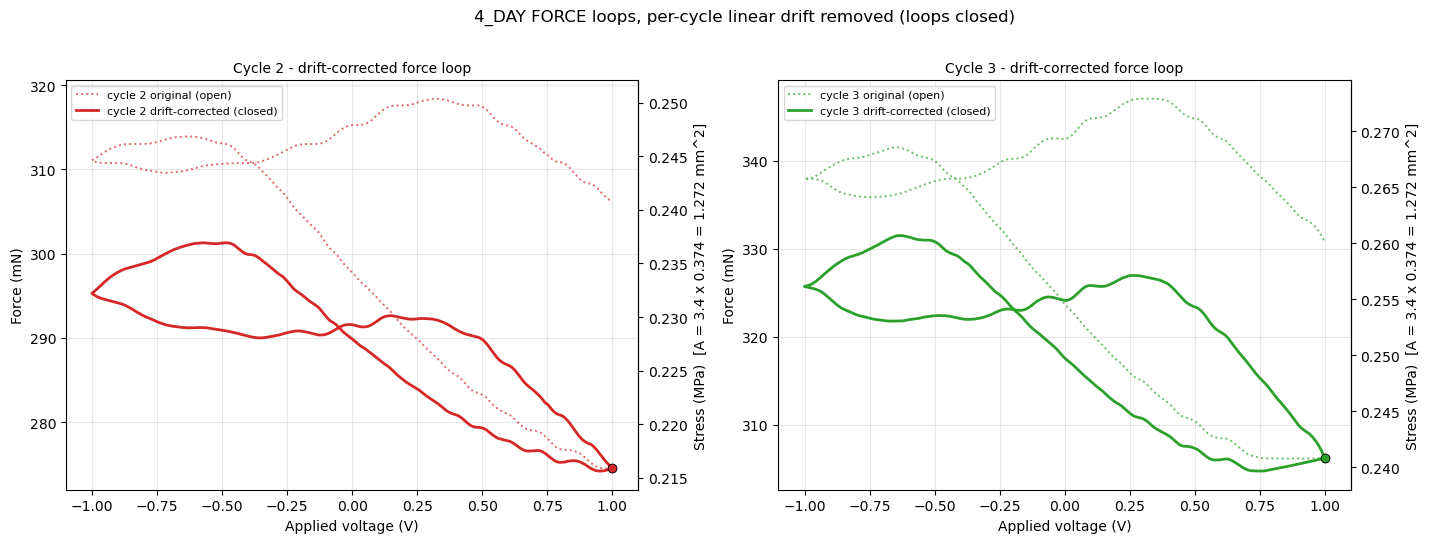

In [5]:
# Focused view: the drift-corrected (closed) loops for the later cycles on their own
# (cycle 1 is typically a conditioning/equilibration scan), original open loop dotted behind.
SHOW_CYCLES = [c for c in (1, 2) if c < n_scans]   # 0-indexed -> cycles 2 and 3
fig2, axes2 = plt.subplots(1, len(SHOW_CYCLES), figsize=(7.5*len(SHOW_CYCLES), 5.5), squeeze=False)
for j, c in enumerate(SHOW_CYCLES):
    color = PALETTE[c % len(PALETTE)]
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')
    ax = axes2[0, j]
    ax.plot(sub['v_applied'], sub['smooth'], color=color, lw=1.4, ls=':', alpha=0.7,
            label=f'cycle {c+1} original (open)')
    ax.plot(sub['v_applied'], sub['smooth_closed'], color=color, lw=2.0,
            label=f'cycle {c+1} drift-corrected (closed)')
    ax.scatter([sub['v_applied'].values[0], sub['v_applied'].values[-1]],
               [sub['smooth_closed'].values[0], sub['smooth_closed'].values[-1]],
               color=color, zorder=5, s=40, ec='k', lw=0.5)
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel(VALUE_LABEL)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax_s = ax.secondary_yaxis('right', functions=(to_sec, from_sec))
    ax_s.set_ylabel(SEC_LABEL)
    ax.set_title(f'Cycle {c+1} - drift-corrected {MODE.lower()} loop', fontsize=10)
fig2.suptitle(f'{DAY_KEY} {MODE} loops, per-cycle linear drift removed (loops closed)', fontsize=12)
fig2.tight_layout(rect=[0, 0, 0.96, 0.97])
plt.show()

## Linear slippage correction

Each scan starts and ends at **+1.0 V**, so the sensor reading at the top of the ramp should be the
same at the start and end of every cycle. The observed drift from start-+1 V to end-+1 V across the
whole run is mechanical **slippage** of the sample in the grips (creep / settling), not real actuation.

We model it as a single **linear drift in time**: fit `signal = a + b·t` through the top-of-scan
reference samples (`v_applied >= V_TOP`), then subtract `b·(t - t0)` from the whole record. This is
the linear-slippage graph from the LENGTH analysis, now applied to FORCE runs too.

Top-of-scan reference samples (v_applied >= 0.98): 96
Slippage rate:  1.932e-04 V/s   ->   1.096e-02 mN/s
Total drift over 4801 s:  +0.9277 V   (+52.5992 force)


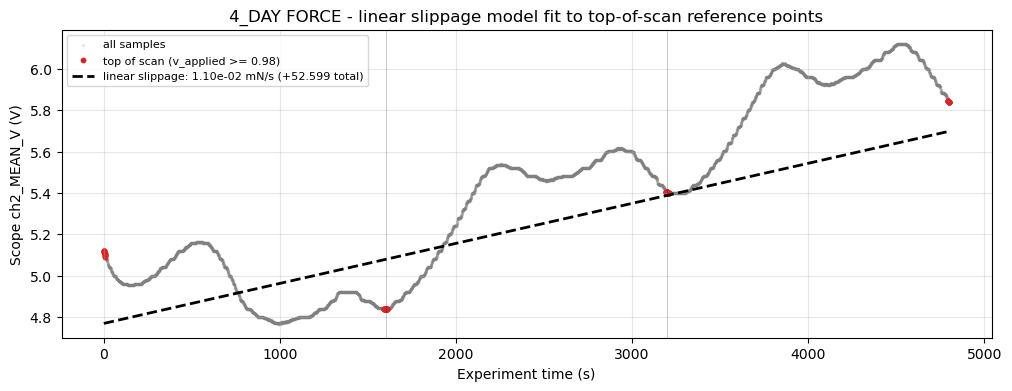

In [6]:
# ---- Fit the linear slippage to the top-of-scan (+1 V) reference points ----
# At v_applied ~ +1 V the "true" reading should be constant across the whole run, so any linear
# trend in the scope signal at those points is pure slippage. Fit it globally and graph the fit.
V_TOP = 0.98   # samples at/above this applied voltage are "top of scan" reference points

t0 = scope_clean['t_exp'].min()
top = scope_clean[scope_clean['v_applied'] >= V_TOP]
b, a = np.polyfit(top['t_exp'].values, top[SCOPE_CHANNEL].values, 1)   # signal ~ a + b*t

span_s = scope_clean['t_exp'].max() - t0
drift_V = b * span_s
print(f'Top-of-scan reference samples (v_applied >= {V_TOP}): {len(top)}')
print(f'Slippage rate:  {b:.3e} V/s   ->   {b*VALUE_COEF:.3e} {RATE_UNIT}')
print(f'Total drift over {span_s:.0f} s:  {drift_V:+.4f} V   ({drift_V*VALUE_COEF:+.4f} {VALUE_LABEL.split()[0].lower()})')

# Subtract the linear trend (anchored at t0 so the absolute level is preserved at start).
scope_clean['corrected'] = scope_clean[SCOPE_CHANNEL] - b * (scope_clean['t_exp'] - t0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(scope_clean['t_exp'], scope_clean[SCOPE_CHANNEL], s=2, alpha=0.12,
           color='gray', label='all samples')
ax.scatter(top['t_exp'], top[SCOPE_CHANNEL], s=10, color='#d62728',
           label=f'top of scan (v_applied >= {V_TOP})')
tt = np.array([t0, scope_clean['t_exp'].max()])
ax.plot(tt, a + b*tt, 'k--', lw=2,
        label=f'linear slippage: {b*VALUE_COEF:.2e} {RATE_UNIT} ({drift_V*VALUE_COEF:+.3f} total)')
for c in range(1, n_scans):
    ax.axvline(c*per_scan_s, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel('Experiment time (s)')
ax.set_ylabel(f'Scope {SCOPE_CHANNEL} (V)')
ax.set_title(f'{DAY_KEY} {MODE} - linear slippage model fit to top-of-scan reference points')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()

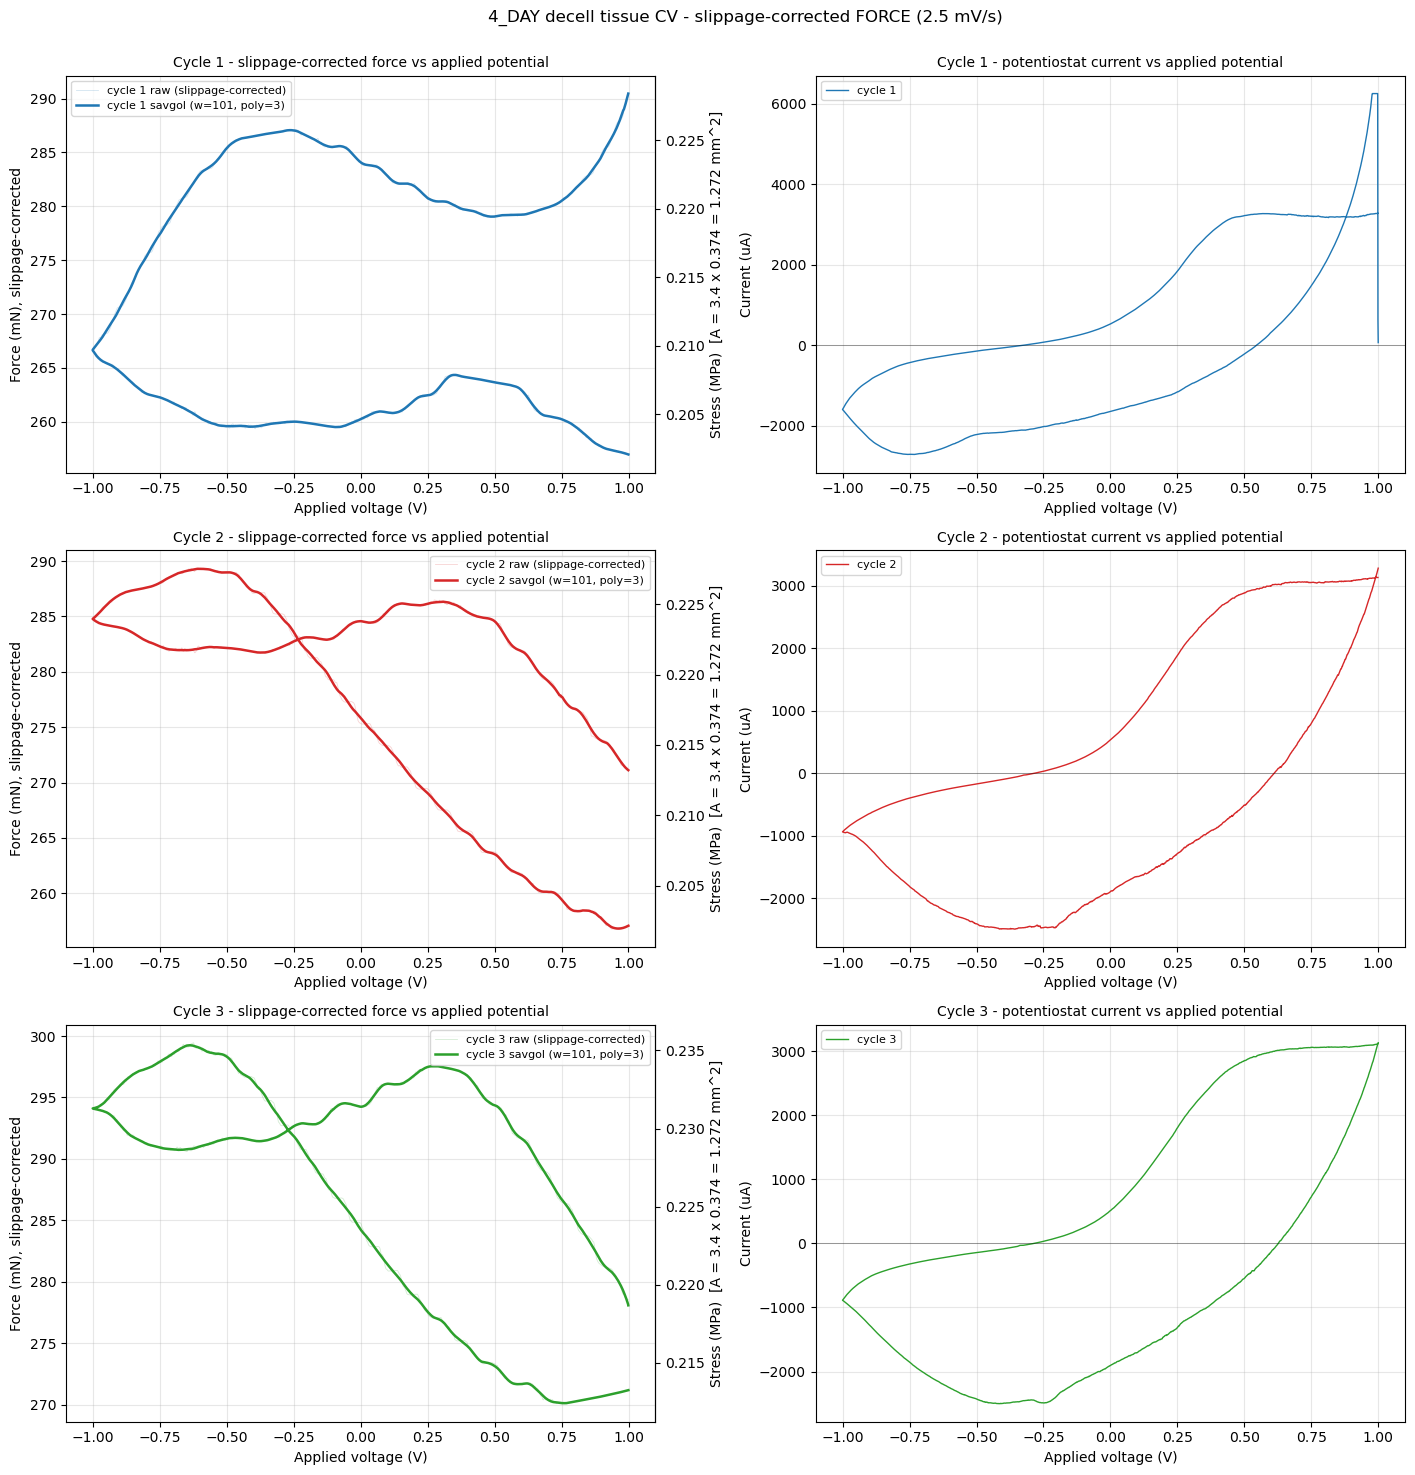

In [7]:
# ---- Replot the CV loops using the slippage-corrected signal ----
# Left panels now use the globally detrended signal so each cycle's start-+1 V and end-+1 V line up.
# Read the swing as the real actuation.
scope_clean['value_corr']  = scope_clean['corrected'] * VALUE_COEF
scope_clean['smooth_corr'] = savgol_per_cycle(scope_clean, 'value_corr', SMOOTH_WINDOW, SAVGOL_POLY)

fig, axes = plt.subplots(n_scans, 2, figsize=(15, 5*n_scans), squeeze=False)
for c in range(n_scans):
    color = PALETTE[c % len(PALETTE)]
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')

    ax = axes[c, 0]
    ax.plot(sub['v_applied'], sub['value_corr'], color=color, lw=0.6, alpha=RAW_ALPHA,
            label=f'cycle {c+1} raw (slippage-corrected)')
    ax.plot(sub['v_applied'], sub['smooth_corr'], color=color, lw=1.8,
            label=f'cycle {c+1} savgol (w={SMOOTH_WINDOW}, poly={SAVGOL_POLY})')
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel(VALUE_LABEL + ', slippage-corrected')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax_s = ax.secondary_yaxis('right', functions=(to_sec, from_sec))
    ax_s.set_ylabel(SEC_LABEL)
    ax.set_title(f'Cycle {c+1} - slippage-corrected {MODE.lower()} vs applied potential', fontsize=10)

    axc = axes[c, 1]
    axc.plot(poten[f'v{c+1}'], poten[f'i{c+1}_uA'], color=color, lw=1.0, label=f'cycle {c+1}')
    axc.set_xlabel('Applied voltage (V)')
    axc.set_ylabel('Current (uA)')
    axc.axhline(0, color='k', lw=0.5, alpha=0.5)
    axc.grid(True, alpha=0.3)
    axc.legend(loc='best', fontsize=8)
    axc.set_title(f'Cycle {c+1} - potentiostat current vs applied potential', fontsize=10)

fig.suptitle(f'{DAY_KEY} decell tissue CV - slippage-corrected {MODE} (2.5 mV/s)', fontsize=12)
fig.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()